In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:

# =====================================
# Create Images Folder
# =====================================
os.makedirs("images", exist_ok=True)

# =====================================
# Load Dataset
# =====================================
df = pd.read_csv("data/water_potability.csv")

print("=" * 50)
print("First 5 Rows")
print(df.head())

print("=" * 50)
print("Dataset Shape")
print(df.shape)

print("=" * 60)
print("Missing Values")
print(df.isnull().sum())

First 5 Rows
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
Dataset Shape
(3276, 10)
Missing Values
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate       

Missing Values After Cleaning
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  3276.000000  3276.000000   3276.000000  3276.000000  3276.000000   
mean      7.074194   196.369496  22014.092526     7.122277   333.608364   
std       1.470040    32.879761   8768.570828     1.583085    36.143851   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.277673   176.850538  15666.690297     6.127421   317.094638   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       7.870050   216.667456  27332.762127     8.114887   350.385756   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Pot

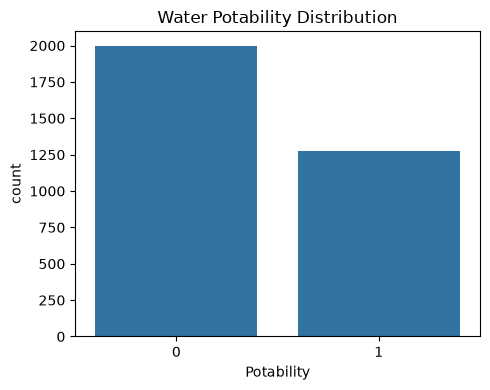

In [4]:
# =====================================
# Handle Missing Values
# =====================================
imputer = SimpleImputer(strategy="median")
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

print("=" * 60)
print("Missing Values After Cleaning")
print(df.isnull().sum())

# =====================================
# Exploratory Data Analysis (EDA)
# =====================================
print(df.describe())

# Target Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Potability", data=df)
plt.title("Water Potability Distribution")
plt.tight_layout()
plt.savefig("images/potability_distribution.png")
plt.show()


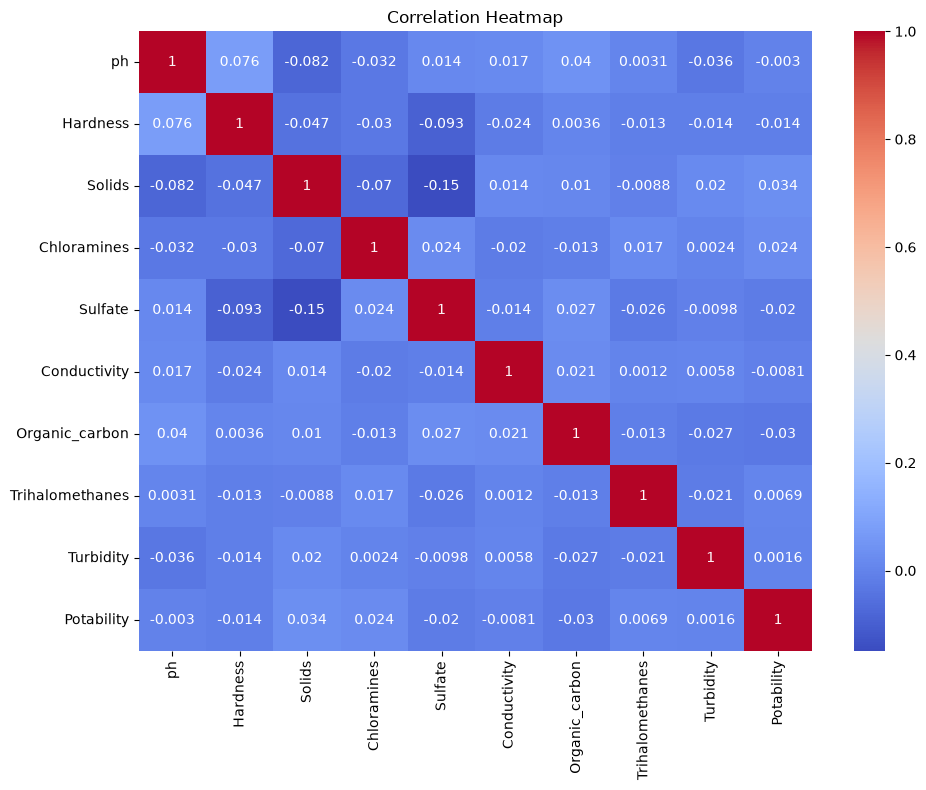

In [5]:

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

In [6]:
# =====================================
# Split Features and Target
# =====================================
X = df.drop("Potability", axis=1)
y = df["Potability"]

# =====================================
# Train/Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [7]:
# =====================================
# Decision Tree Model
# =====================================
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

# Prediction
y_pred = tree.predict(X_test)

# =====================================
# Evaluation
# =====================================
print("\n========== Decision Tree Results ==========")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


========== Decision Tree Results ==========
Accuracy : 0.5960365853658537
Precision: 0.48132780082987553
Recall   : 0.453125
F1 Score : 0.46680080482897385

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.69      0.67       400
           1       0.48      0.45      0.47       256

    accuracy                           0.60       656
   macro avg       0.57      0.57      0.57       656
weighted avg       0.59      0.60      0.59       656



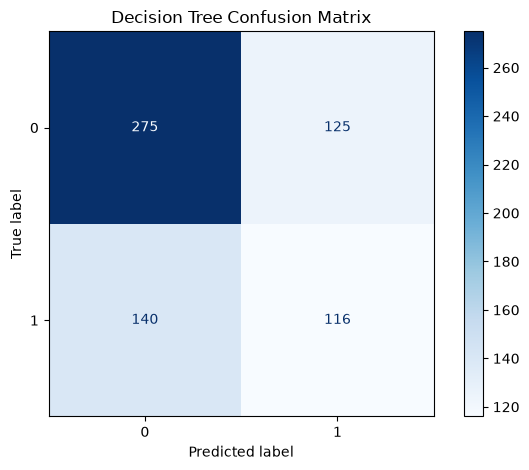

In [8]:
# =====================================
# Confusion Matrix
# =====================================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.savefig("images/confusion_matrix_tree.png")
plt.show()

In [9]:
# =====================================
# Hyperparameter Tuning
# =====================================
params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n========== Best Model ==========")
print("Best Parameters :", grid.best_params_)
print("Best CV Score   :", grid.best_score_)



========== Best Model ==========
Best Parameters : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score   : 0.6370229007633588


In [10]:
# =====================================
# Best Model Evaluation
# =====================================
best_tree = grid.best_estimator_

y_best = best_tree.predict(X_test)

print("\n========== Best Decision Tree ==========")
print("Accuracy :", accuracy_score(y_test, y_best))
print("Precision:", precision_score(y_test, y_best))
print("Recall   :", recall_score(y_test, y_best))
print("F1 Score :", f1_score(y_test, y_best))



========== Best Decision Tree ==========
Accuracy : 0.625
Precision: 0.5396825396825397
Recall   : 0.265625
F1 Score : 0.35602094240837695



Feature Importance
           Feature  Importance
4          Sulfate    0.397044
0               ph    0.178583
3      Chloramines    0.124733
1         Hardness    0.104983
7  Trihalomethanes    0.064881
2           Solids    0.060695
8        Turbidity    0.039490
5     Conductivity    0.029592
6   Organic_carbon    0.000000


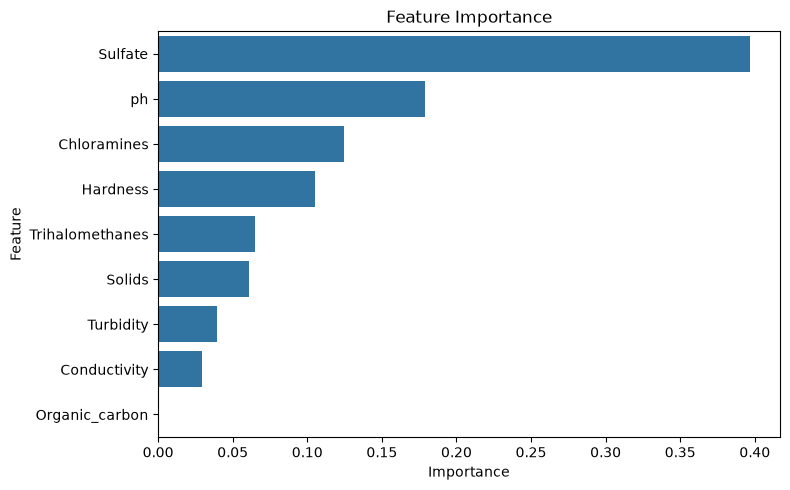

In [11]:
# =====================================
# Feature Importance
# =====================================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png")
plt.show()


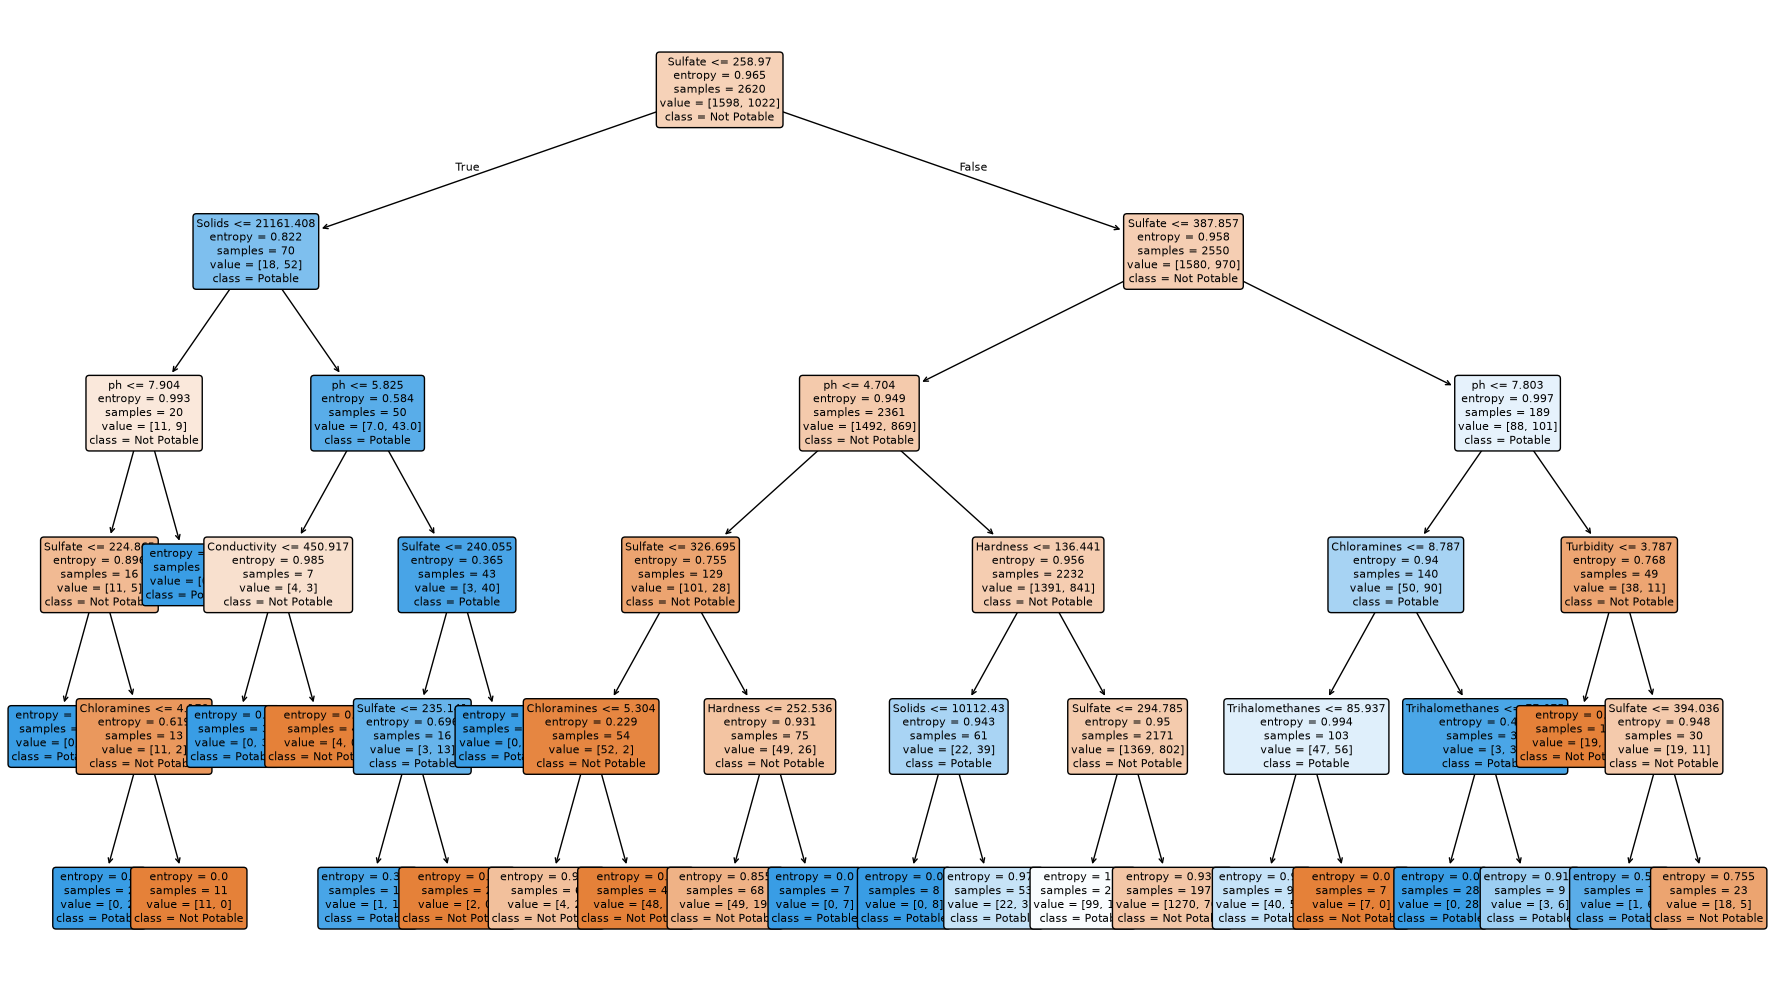


Project Completed Successfully!


In [12]:
# =====================================
# Decision Tree Visualization
# =====================================
plt.figure(figsize=(18,10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=["Not Potable", "Potable"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.tight_layout()
plt.savefig("images/decision_tree.png")
plt.show()

print("\nProject Completed Successfully!")